# Sentiment Analysis on Twitter Dataset
This notebook explores, preprocesses, and models the Twitter dataset for sentiment analysis.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Install necessary libraries

In [ ]:
# Data handling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
# Text preprocessing
import re
import string

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Deep Learning (LSTM)
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from sklearn.preprocessing import LabelEncoder

# Transformers (BERT, RoBERTa)

# Install Hugging Face Transformers and Datasets
!pip install transformers datasets sentencepiece --quiet

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Preprocessing

In [ ]:
col_names = ["sentiment", "id", "date", "query", "user", "text"]

data = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/training.1600000.processed.noemoticon.csv",
    encoding="latin-1",
    names=col_names
)

In [ ]:
data.head()

,sentiment,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   sentiment  1600000 non-null  int64 
 1   id         1600000 non-null  int64 
 2   date       1600000 non-null  object
 3   query      1600000 non-null  object
 4   user       1600000 non-null  object
 5   text       1600000 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


In [ ]:
# Keep only relevant columns
data = data[['sentiment', 'text']]

In [ ]:
data.head()

,sentiment,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


from matplotlib import pyplot as plt
import seaborn as sns
_df_0.groupby('text').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['sentiment']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'sentiment'}, axis=1)
              .sort_values('sentiment', ascending=True))
  xs = counted['sentiment']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_1.sort_values('sentiment', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('text')):
  _plot_series(series, series_name, i)
  fig.legend(title='text', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('sentiment')
_ = plt.ylabel('count()')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 2 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   sentiment  1600000 non-null  int64 
 1   text       1600000 non-null  object
dtypes: int64(1), object(1)
memory usage: 24.4+ MB


#Map Sentiment Values

Assuming your dataset uses 0 = negative, 4 = positive (common for this dataset):

In [ ]:
data['sentiment'] = data['sentiment'].map({0:0, 4:1})
data['sentiment'].value_counts()

,count
sentiment,
0,800000
1,800000


Text Cleaning Function

In [ ]:
def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#', '', text)
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
data['clean_text'] = data['text'].apply(clean_text)

# Preview cleaned text
data[['text', 'clean_text']].head()


,text,clean_text
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",a thats a bummer you shoulda got david carr of...
1,is upset that he can't update his Facebook by ...,is upset that he cant update his facebook by t...
2,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sav...
3,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire
4,"@nationwideclass no, it's not behaving at all....",no its not behaving at all im mad why am i her...


Train-Test Split

In [ ]:
X = data['clean_text']
y = data['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1280000
Testing samples: 320000


# LSTM Model

In [ ]:
# Ensure labels are integers
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

Tokenize Text

In [ ]:
# Set max number of words and sequence length
MAX_WORDS = 10000
MAX_LEN = 100

# Tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences to same length
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

Build LSTM Model

In [ ]:
EMBEDDING_DIM = 100

model = Sequential()
model.add(Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LEN))
model.add(Bidirectional(LSTM(128, return_sequences=False)))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))  # Binary classification

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Train LSTM Model

In [ ]:
EPOCHS = 5
BATCH_SIZE = 128

history = model.fit(
    X_train_pad, y_train_enc,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/5
9000/9000 ━━━━━━━━━━━━━━━━━━━━ 174s 19ms/step - accuracy: 0.7819 - loss: 0.4561 - val_accuracy: 0.8183 - val_loss: 0.3968
Epoch 2/5
9000/9000 ━━━━━━━━━━━━━━━━━━━━ 169s 19ms/step - accuracy: 0.8245 - loss: 0.3881 - val_accuracy: 0.8240 - val_loss: 0.3868
Epoch 3/5
9000/9000 ━━━━━━━━━━━━━━━━━━━━ 169s 19ms/step - accuracy: 0.8355 - loss: 0.3676 - val_accuracy: 0.8266 - val_loss: 0.3834
Epoch 4/5
9000/9000 ━━━━━━━━━━━━━━━━━━━━ 168s 19ms/step - accuracy: 0.8438 - loss: 0.3513 - val_accuracy: 0.8258 - val_loss: 0.3842
Epoch 5/5
9000/9000 ━━━━━━━━━━━━━━━━━━━━ 169s 19ms/step - accuracy: 0.8513 - loss: 0.3361 - val_accuracy: 0.8261 - val_loss: 0.3941


In [ ]:
# Evaluate on test data
loss, accuracy = model.evaluate(X_test_pad, y_test_enc)
print("Test Accuracy:", accuracy)

10000/10000 ━━━━━━━━━━━━━━━━━━━━ 60s 6ms/step - accuracy: 0.8258 - loss: 0.3968
Test Accuracy: 0.8254187703132629


Predictions


In [ ]:
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

10000/10000 ━━━━━━━━━━━━━━━━━━━━ 43s 4ms/step


Confusion matrix

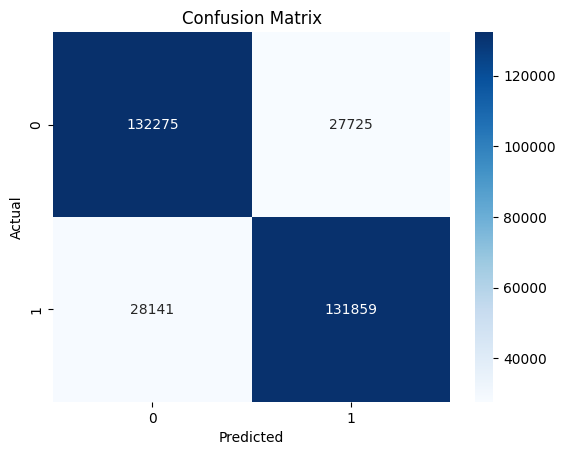

In [ ]:
cm = confusion_matrix(y_test_enc, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Classification report

In [ ]:
print(classification_report(y_test_enc, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.82      0.82    160000
           1       0.82      0.83      0.83    160000

    accuracy                           0.83    320000
   macro avg       0.83      0.83      0.83    320000
weighted avg       0.83      0.83      0.83    320000



# BERT Model

Prepare Dataset for Hugging Face

In [ ]:
# Convert train and test sets to Hugging Face Dataset format
train_dict = {"text": X_train.tolist(), "label": y_train.tolist()}
test_dict = {"text": X_test.tolist(), "label": y_test.tolist()}

train_dataset = Dataset.from_dict(train_dict)
test_dataset = Dataset.from_dict(test_dict)

print(train_dataset)
print(test_dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 1280000
})
Dataset({
    features: ['text', 'label'],
    num_rows: 320000
})


Reduce Dataset Size

In [ ]:
# Reduce dataset size to speed up training
train_dataset = train_dataset.shuffle(seed=42).select(range(200000))
test_dataset = test_dataset.shuffle(seed=42).select(range(20000))


Load Tokenizer & Tokenize Dataset

In [ ]:
MODEL_NAME = "bert-base-uncased"  # for faster training

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=64)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Set format for PyTorch
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/200000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Load Pretrained BERT Model

In [ ]:
# Binary classification: num_labels=2
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Define Metrics Function

In [ ]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

Training Arguments

In [ ]:
!pip install --upgrade transformers --quiet

In [ ]:
training_args = TrainingArguments(
    output_dir="./bert-twitter-sentiment",
    do_eval=True,
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir='./logs',
)

Initialize Trainer

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

/tmp/ipython-input-2388959174.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Train BERT Model

In [ ]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: qamarabbas0332-69 (qamarabbas-fast-nuces) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss


KeyboardInterrupt: 

Evaluate BERT Model

In [ ]:
results = trainer.evaluate()
print("Evaluation results:", results)

Predictions

In [ ]:
preds = trainer.predict(test_dataset)
y_pred = preds.predictions.argmax(-1)
y_true = preds.label_ids

Confusion matrix

In [ ]:
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Classification Report

In [ ]:
print(classification_report(y_true, y_pred))

# Compare LSTM & BERT Models

Compare Accuracy, Precision, Recall, F1

In [ ]:
metrics = ['precision', 'recall', 'f1-score', 'accuracy']

lstm_scores = [cr_lstm['1'][m] if m != 'accuracy' else cr_lstm['accuracy'] for m in metrics]
bert_scores = [cr_bert['1'][m] if m != 'accuracy' else cr_bert['accuracy'] for m in metrics]

In [ ]:

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(x - width/2, lstm_scores, width, label='LSTM')
ax.bar(x + width/2, bert_scores, width, label='BERT')

ax.set_ylabel("Score")
ax.set_title("Model Comparison")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0,1)
ax.legend()
plt.show()

In [3]:
!git remote add origin https://github.com/qamar-prog/ML-Project.git

fatal: not a git repository (or any of the parent directories): .git


In [4]:
git branch -M main

SyntaxError: invalid syntax (1692283080.py, line 1)